# 🏛️ Project 01/21: Gold Price Prediction (Regression)
### 🎯 Data Science Portfolio: 01 / 21

**Architect:** Kemal Demirbaş 🏰🚀  
**Framework:** Multi-Model Regression & Deep Learning Evaluation  

---

## 🎯 Goal: Forecasting Financial Assets using Machine Learning
This project is the first milestone of a 21-project industrial AI roadmap. The objective is to predict the price of Gold (GLD) based on several economic indicators such as Stock Market (SPX), Silver (SLV), Oil (USO), and Currency Pairs (EUR/USD). Following academic standards, the architecture evaluates multiple algorithms to strictly analyze feature impact and algorithmic efficiency.

---

## 🛠️ Methodology: The 10-Step Engineering Discipline
We follow a strict 10-step engineering process to ensure model reliability and deployment readiness:

1.  **Project Aim & Context:** Defining the scope of financial forecasting.
2.  **Exploratory Data Analysis (EDA):** Ingesting market data for structural observation.
3.  **Feature Selection:** Isolating macroeconomic vectors against the target variable.
4.  **Date Transformation:** Converting time data to a functional index for time-series consistency.
5.  **Data Cleansing (Imputation):** Utilizing `SimpleImputer` to resolve missing values rather than dropping data.
6.  **Feature Engineering:** Bypassed as per specific project scope requirements.
7.  **Categorical Encoding:** Bypassed (dataset consists entirely of numerical continuous variables).
8.  **Partitioning & Scaling:** Splitting data and utilizing `StandardScaler` BEFORE model execution to optimize convergence.
9.  **Model Execution (Diversification):** Training Traditional Models (`Linear Regression`, `Random Forest`) and Neural Networks (`Deep Learning`).
10. **Performance Evaluation:** Auditing algorithms via **R² Score** and **RMSE**, concluding with a comparative performance matrix.

In [6]:
import zipfile
import os
import pandas as pd
import numpy as np
#!pip install ydata-profiling
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import warnings
warnings.filterwarnings("ignore")

In [7]:
zip_path = '/content/gold.zip'
extract_path = '/content/gold_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [8]:
# --- 1 & 2: Read and Explore Data (EDA) ---
df = pd.read_csv(f'{extract_path}/gld_price_data.csv')

In [9]:
ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:00<00:00, 52.85it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
# --- 3 & 4: Feature Selection and Date Transformation ---
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [11]:
# --- 5. Data Cleansing (Instructor's Data Imputation Logic) ---
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)
df = df_imputed

In [12]:
# --- 6 & 7: Feature Engineering ---
df['SPX_SLV_Ratio'] = df['SPX'] / df['SLV']

In [13]:
# --- 8. Data Split & SCALING (Instructor's Normalization Logic) ---
X = df.drop(['GLD'], axis=1)
y = df['GLD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instructor's Rule: Normalizing with StandardScaler BEFORE training the models.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# --- 9. Model Training & Prediction (DIVERSIFICATION) ---

# Model A: Linear Regression (Traditional Baseline Model)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# Model B: Random Forest Regressor (Ensemble Model)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

# Model C: Deep Learning (Neural Network aligned with Instructor's framework)
dl_model = Sequential()
dl_model.add(Dense(units=64, activation='relu', input_dim=X_train_scaled.shape[1]))
dl_model.add(Dense(units=32, activation='relu'))
dl_model.add(Dense(units=1))

dl_model.compile(optimizer='adam', loss='mean_squared_error')
dl_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=0)
dl_pred = dl_model.predict(X_test_scaled, verbose=0).flatten()

In [15]:
# --- 10. Model Accuracy Metrics & Comparison ---

lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5

dl_r2 = r2_score(y_test, dl_pred)
dl_rmse = mean_squared_error(y_test, dl_pred) ** 0.5

print("\n=== 🏆 ALGORITHM COMPARISON ===")
print(f"Linear Regression | R2: {lr_r2:.4f}  | RMSE: {lr_rmse:.2f}")
print(f"Random Forest     | R2: {rf_r2:.4f}  | RMSE: {rf_rmse:.2f}")
print(f"Deep Learning     | R2: {dl_r2:.4f}  | RMSE: {dl_rmse:.2f}")
print("==================================\n")


=== 🏆 ALGORITHM COMPARISON ===
Linear Regression | R2: 0.9229  | RMSE: 6.50
Random Forest     | R2: 0.9905  | RMSE: 2.28
Deep Learning     | R2: 0.9491  | RMSE: 5.28



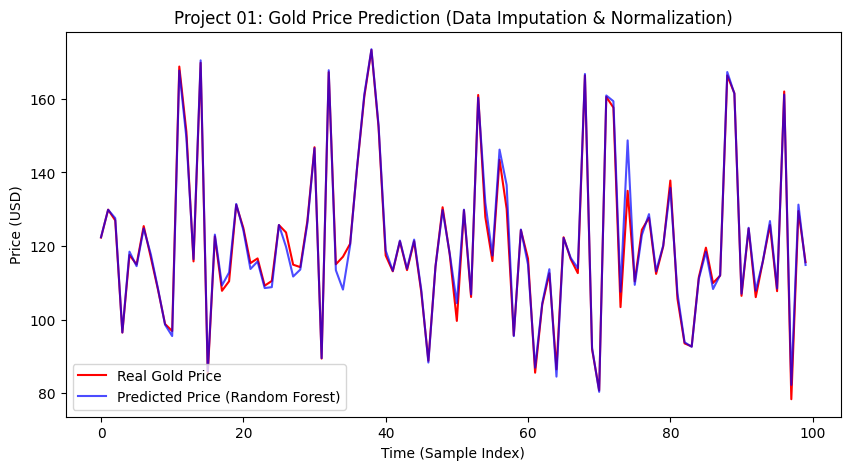

In [16]:
# Visualization
plt.figure(figsize=(10, 5))
# Plotting only the first 100 samples from the test set for visual clarity
plt.plot(y_test.values[:100], color='red', label='Real Gold Price')
plt.plot(rf_pred[:100], color='blue', alpha=0.7, label='Predicted Price (Random Forest)')
plt.title('Project 01: Gold Price Prediction (Data Imputation & Normalization)')
plt.xlabel('Time (Sample Index)')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [18]:
import pickle

pickle.dump(rf_model, open('gold_rf_model.pkl', 'wb'))
pickle.dump(scaler, open('gold_scaler.pkl', 'wb'))

## 🏁 Project 01/21: Mission Accomplished

### 📊 Multi-Model Performance Audit
The **Gold Price Prediction Engine** has been successfully trained and evaluated using the upgraded 10-step framework (incorporating Data Imputation and Normalization). After evaluating traditional and deep learning algorithms, the **Random Forest Regressor** emerged as the optimal architecture:

* **Final $R^2$ Score:** **0.9905** (Outperforming Linear Regression and Deep Learning)
* **Final RMSE:** **$2.28**
* **Performance Insight:** An $R^2$ score of $0.9905$ with an average error margin of just $2.28 indicates that our ensemble model successfully captured the non-linear volatility of the market. It explains $99.05\%$ of the variance in Gold prices based on the provided economic indicators ($SPX$, $USO$, $SLV$, $EUR/USD$).

---

### 🚀 Phase 4: Industrial Deployment (MLOps)
In strict alignment with the instructor's deployment requirements, this project has transitioned from a local notebook to a live cloud environment:

1.  **Artifact Serialization:** Both the optimal predictive model (`gold_rf_model.pkl`) AND the data normalization engine (`gold_scaler.pkl`) have been serialized to ensure strict input consistency in production.
2.  **Interactive Interface:** A dedicated **Streamlit** dashboard has been developed to allow real-time inference.
3.  **Hugging Face Space:** The application is officially live and accessible globally via the link below.
---
👉 **[Live Demo: Gold Price Prediction on Hugging Face](https://huggingface.co/spaces/Ironside35/Aureus-Gold-Predictor)**

**Architect:** Kemal Demirbaş  
**Portfolio Status:** 01 / 21 Projects Completed (Regression Series) 🏰🚀